In [6]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import requests
from bs4 import BeautifulSoup 
import numpy as np
import matplotlib.pyplot as plt

# P3 Limpieza csv

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vickyotarola/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df = pd.read_csv('../data/corpus_v1.csv')

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-z\s]', '', texto)
    words = texto.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df['texto_limpio'] = df['texto'].apply(limpiar_texto)
vocabulario_total = set(" ".join(df['texto_limpio']).split())
print(f"Tamaño del vocabulario final: {len(vocabulario_total)} palabras únicas.")

df.to_csv('../data/corpus_limpio.csv', index=False)

Tamaño del vocabulario final: 6877 palabras únicas.


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vickyotarola/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:

df = pd.read_csv('../data/corpus_limpio.csv')
filas_vacias = df['texto_limpio'].isna()
for index, row in df[filas_vacias].iterrows():
    url = row['url']
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        respuesta = requests.get(url, headers=headers, timeout=10)
        if respuesta.status_code == 200:
            soup = BeautifulSoup(respuesta.text, 'html.parser')
            parrafos = soup.find_all('p')
            texto_extraido = " ".join([p.get_text() for p in parrafos])
            if len(texto_extraido) > 50:
                df.at[index, 'texto_limpio'] = texto_extraido
                print(f"Recuperado: {url}")
            else:
                print(f"La página cargó, pero no se encontró texto en: {url}")
        else:
            print(f"Error {respuesta.status_code} al acceder a: {url}")
    except Exception as e:
        print(f"Fallo de conexión con {url}: {e}")

df.to_csv('../data/corpus_recuperado.csv', index=False)

Recuperado: https://investors.palantir.com/news-details/2026/Palantir-Joins-U-S--Army-and-Industry-Partners-for-Right-to-Integrate-Hackathon-Sprint-for-Defense-wide-Interoperability/
Recuperado: https://investors.palantir.com/news-details/2026/GE-Aerospace-and-Palantir-Expand-Partnership-to-Transform-Military-Aircraft-Readiness-with-AI/
La página cargó, pero no se encontró texto en: https://www.palantir.com/q1-2026-letter/en/
La página cargó, pero no se encontró texto en: https://www.palantir.com/newsroom/letters/aip-in-action/en/
La página cargó, pero no se encontró texto en: https://www.palantir.com/q4-2025-letter/en/
La página cargó, pero no se encontró texto en: https://www.palantir.com/newsroom/press-releases/palantir-and-oracle-announce-strategic-partnership/
La página cargó, pero no se encontró texto en: https://www.palantir.com/newsroom/press-releases/palantir-and-panasonic-energy-expand-partnership/
La página cargó, pero no se encontró texto en: https://www.palantir.com/newsro

# P4 Creacion Matriz

In [11]:
df = pd.read_csv('../data/corpus_recuperado.csv')
df_valido = df.dropna(subset=['texto_limpio']).copy()
vectorizador = TfidfVectorizer()
X = vectorizador.fit_transform(df_valido['texto_limpio'])
A_sparse = X.T
A = A_sparse.toarray()
m, n = A.shape
vocabulario = vectorizador.get_feature_names_out()
print(f"Dimensiones de la matriz A: {m} (terminos) x {n} (documentos)")

Dimensiones de la matriz A: 6970 (terminos) x 41 (documentos)


# P5 Calculo de la SVD


In [12]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(S)
print(f"Dimensiones de U: {U.shape}, Sigma: {Sigma.shape}, Vt: {Vt.shape}")

Dimensiones de U: (6970, 41), Sigma: (41, 41), Vt: (41, 41)


# P6 Visualizacion

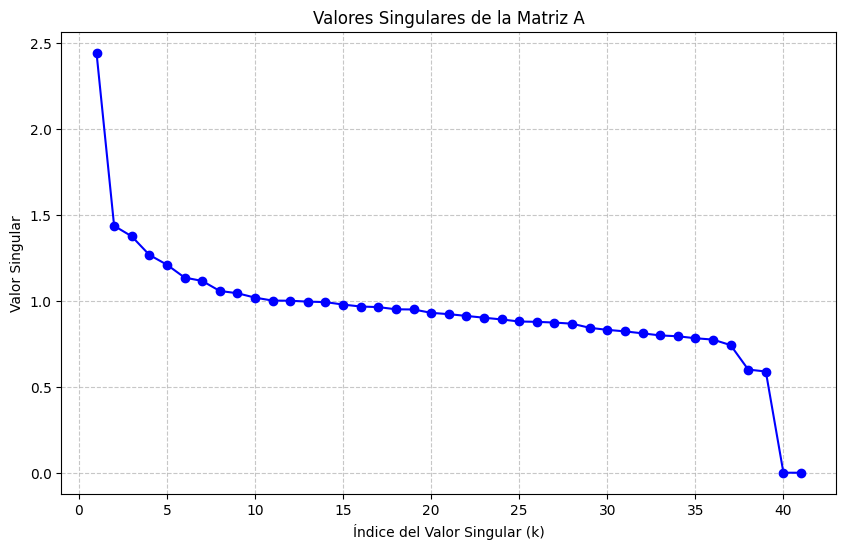

In [ ]:
#Creamos el grafico para los valores singulares
plt.figure(figsize=(10,6))
plt.plot(range(1, len(S) + 1), S, marker='o', linestyle='-', color='b') 
plt.title('Valores Singulares de la Matriz A')
plt.xlabel('Índice del Valor Singular (k)')
plt.ylabel('Valor Singular')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("../figures/valores_singulares.png", bbox_inches='tight')
plt.show()



Para elegir el valor de k, vamos a utilizar el método del codo, el cual es una forma sencilla e intuitiva de encontrar el número óptimo de valores singulares para SVD. 

Vamos a observar la visualizacion de los valores singulares en orden descendente y buscar un punto en el que la curva se doble bruscamente, como un codo. Este punto nos indica que los valores singulares restantes tienen poca contribución a los datos y se pueden descartar sin perder mucha información. 

Observando el gráfico vemos que hay una caída inmensa entre k=1 y k=2, pero se sigue cayendo de forma visible hasta k=5 o k=6.
A partir de k=6 en adelante, la curva se vuelve mucho más plana y con una pendiente suave, hasta que finalmente cae a cero cerca de k=39 

Vamos a elegir k=6, , ya que es el punto donde la curva realmente se empieza a estabilizar de forma casi horizontal y además el elegir este k nos sirve para reducir el ruido. Nuestra eleccion de este k para la representación reducida, se basa en que estas primeras componentes van a concentrar la mayor parte de la estructura semántica relevante del corpus, mientras que las componentes posteriores probablemente representen ruido o detalles marginales."

Igualmente tenemos en cuenta que si bien el método del codo es fácil de implementar y visualizar, puede ser subjetivo y sensible al ruido.

# P7 Representacion de documentos y terminos en baja dimension


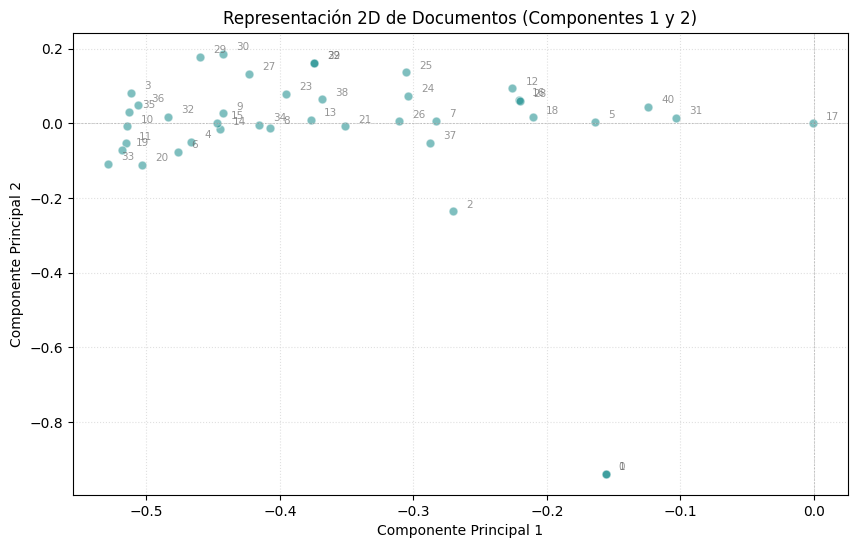

In [34]:
# Reducimos el espacio a k=6 componentes principales
k = 6

# Extraemos las componentes para k=6
Uk = U[:, :k]
Sk = np.diag(S[:k])
Vtk = Vt[:k, :]

# Calculamos las coordenadas en el espacio latente 6D
# Documentos: D_k = S_k * V^T_k (Dimensión: 6 x 41)
Dk = Sk @ Vtk  

# Términos: T_k = U_k * S_k (Dimensión: 6970 x 6)
Tk = Uk @ Sk  

# Elegimos el par de componentes a graficar (0 y 1 son la 1ra y 2da componente)
comp_x = 0 
comp_y = 1 

plt.figure(figsize=(10, 6))

plt.scatter(Dk[comp_x, :], Dk[comp_y, :], alpha=0.5, color='teal', edgecolors='white', linewidth=0.8, s=40)
for i in range(Dk.shape[1]):
    plt.annotate(str(i), 
                 (Dk[comp_x, i] + 0.01, Dk[comp_y, i] + 0.01), 
                 fontsize=7.5,      
                 alpha=0.7,       
                 color='dimgrey')

plt.title(f'Representación 2D de Documentos (Componentes {comp_x+1} y {comp_y+1})')
plt.xlabel(f'Componente Principal {comp_x+1}')
plt.ylabel(f'Componente Principal {comp_y+1}')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

# Una grilla más suave
plt.grid(True, linestyle=':', color='lightgrey', alpha=0.7)

plt.savefig("../figures/documentos_2d.png", bbox_inches='tight', dpi=300) # dpi=300 mejora la resolución
plt.show()

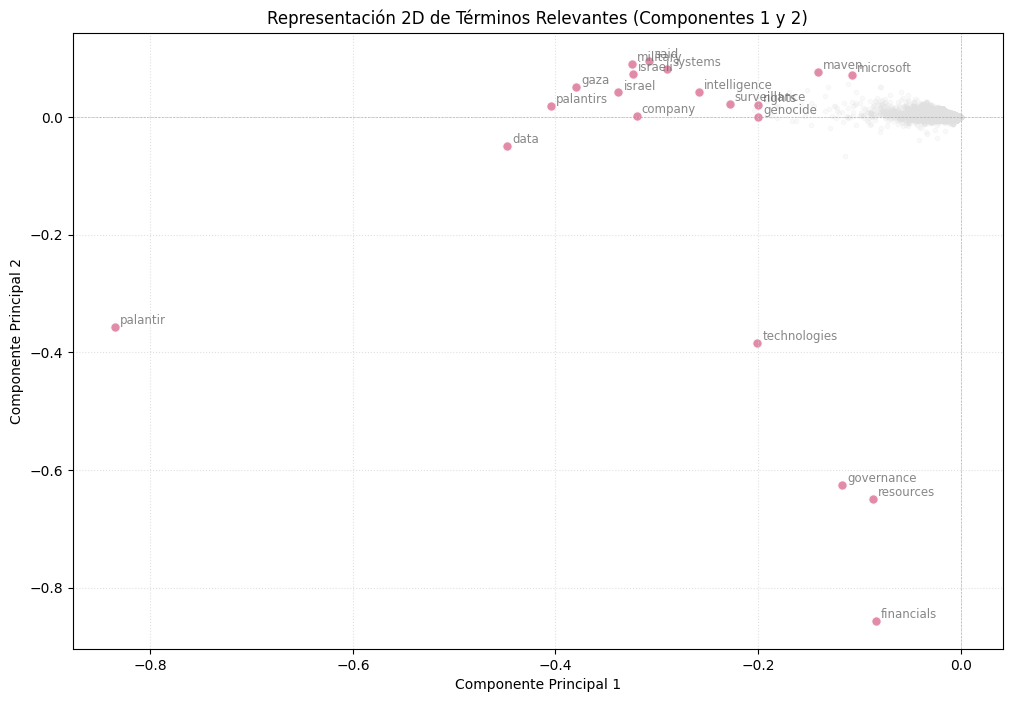

In [33]:
# Visualización de Términos Relevantes 

# Calculamos la magnitud de cada palabra en el espacio 6D completo para encontrar las más importantes
normas_k = np.linalg.norm(Tk, axis=1)
indices_top_terminos = np.argsort(normas_k)[::-1][:20] # Elegimos las 20 palabras con mayor magnitud

plt.figure(figsize=(12, 8))
plt.scatter(Tk[:, comp_x], Tk[:, comp_y], alpha=0.15, color='#e0e0e0', s=10)

# Destacamos los términos más importantes
plt.scatter(Tk[indices_top_terminos, comp_x], Tk[indices_top_terminos, comp_y], 
            color='palevioletred', edgecolors='white', linewidth=0.8, s=45, alpha=0.8)

# Añadimos las etiquetas de texto solo a esos términos top
for i in indices_top_terminos:
    # Redujimos un poco el desplazamiento para que el texto quede más pegadito al punto
    plt.annotate(vocabulario[i], 
                 (Tk[i, comp_x] + 0.005, Tk[i, comp_y] + 0.005),
                 fontsize=8.5,    # Letra un poco más pequeña
                 alpha=0.8,
                 color='dimgrey')

plt.title(f'Representación 2D de Términos Relevantes (Componentes {comp_x+1} y {comp_y+1})')
plt.xlabel(f'Componente Principal {comp_x+1}')
plt.ylabel(f'Componente Principal {comp_y+1}')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.grid(True, linestyle=':', color='lightgrey', alpha=0.7)
plt.savefig("../figures/terminos_2d.png", bbox_inches='tight', dpi=300)
plt.show()

In [25]:
# Ver de qué trata el documento 0 y 1 (los atípicos de abajo)
print("Doc 0:", df_valido.iloc[0]['url']) # o 'texto'
print("Doc 1:", df_valido.iloc[1]['url'])

# Compararlos con documentos de la nube principal (ej. 29 y 30)
print("Doc 29:", df_valido.iloc[29]['url'])
print("Doc 30:", df_valido.iloc[30]['url'])

Doc 0: https://investors.palantir.com/news-details/2026/Palantir-Joins-U-S--Army-and-Industry-Partners-for-Right-to-Integrate-Hackathon-Sprint-for-Defense-wide-Interoperability/
Doc 1: https://investors.palantir.com/news-details/2026/GE-Aerospace-and-Palantir-Expand-Partnership-to-Transform-Military-Aircraft-Readiness-with-AI/
Doc 29: https://apnews.com/article/israel-palestinians-ai-weapons-430f6f15aab420806163558732726ad9
Doc 30: https://apnews.com/article/israel-palestinians-ai-technology-737bc17af7b03e98c29cec4e15d0f108



### El eje Y
El eje y, es decir el componente principal 2 está dividiendo la información de nuestro corpus evidentemente en dos mundos con vocabularios totalmente distintos

- zona superior (Y positivo): Aqui se nota que hay un cluster muy denso, y a medida que aumentamos la cantidad de palabras se densifica más, las palabras como "military", "gaza", "surveullance", "genocide" se encuentran en esta parte de nuesto gradico. Este grupo creemos que representa claramente el rol que tiene la empresa Palantir en conflictos geopoliticos y contratos de defensa y seguridad. Es el escenario donde podemos cuestionar los sistemas sociotecnicos de esta empresa, para entender mejor las fuertes implicancias que tiene a nivel ético y social, ya nuestro modelo logro aislar la controversia algoritmica y militar en este cuadrante

- zona inferior (Y negativo): es el extremo opuesto al anterior, vemos terminos como "financials", "governance" y "resources". Este grupo nos representa el lado netamente corporativo, administrativo y burocratico.

### El eje X

- Podemos observar que la palabra Palantir está muy alejada hacia la izquierda, y la significancia de esto es que es el tema central que cruza la gran mayoria de los documentos en el corpus, por lo tanto, es tambien el tema que captura una mayor "varianza" o peso en la primera componente principal

Podemos entender los ejemplos siguientes como demostraciónes concretas de relaciones:

- La cercanía extrema entre "surveillance", "intelligence", "military" y los nombres de zonas de conflicto, como "gaza" confirmarian que, dentro de este corpus que hemos construido, la vigilancia tecnologíca y la recolección de datos se discuten de la mano con la inteligencia militar y no como una herramienta comercial sin implicaciones.
- Igualmente es revelador notar como la palabra "technologies" se ubica en el centro, funcionando como un puente entre las zonas, mientras que palabras como "fiancials" y "genocide" están en los extremos opuestos del gráfico. Esto nos indica que matematicamente podemos demostrar que los documentos que reportan el exito corporativo y financiero están a su vez aislando por completo el vocabulario relacionado con el impacto etico y humano de los conflicos armados en los que se ven involucrados